<a href="https://colab.research.google.com/github/luffy-loop/Machine_Learning/blob/main/Lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Weight: 10.976627096430459
Bias: 1.7546483001536652


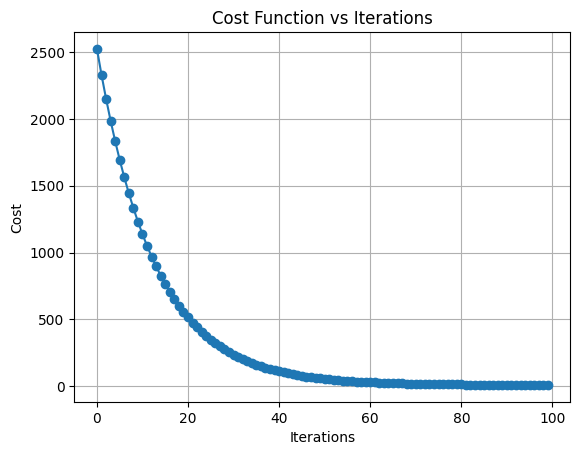

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Data
x = np.array([1,2,3,4,5,6,7,8,9,10], dtype=float)
y = np.array([20,30,40,50,60,70,80,90,100,110], dtype=float)

# Gradient Descent
w = 0
b = 0
lr = 0.001
iterations = 100

cost_history = []

for i in range(iterations):

    y_pred = w*x + b
    error = y_pred - y

    cost = np.mean(error**2) / 2
    cost_history.append(cost)

    dw = np.mean(error*x)
    db = np.mean(error)

    w = w - lr*dw
    b = b - lr*db

print("Weight:", w)
print("Bias:", b)

# Plot
plt.plot(cost_history, marker='o')
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost Function vs Iterations")
plt.grid()
plt.show()

GD: w = 10.981145995841498 b = 1.7785804842391846
GD MSE = 19.773714905013918


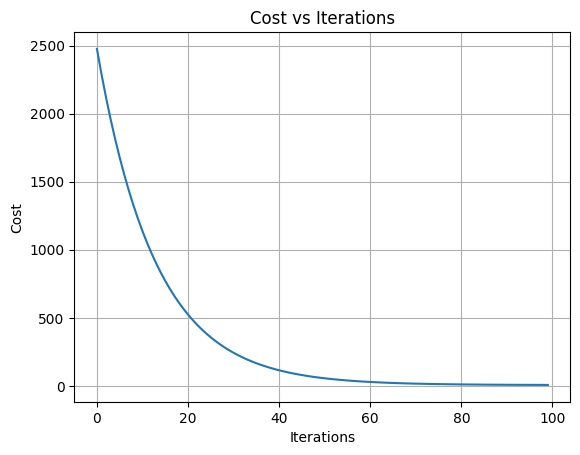

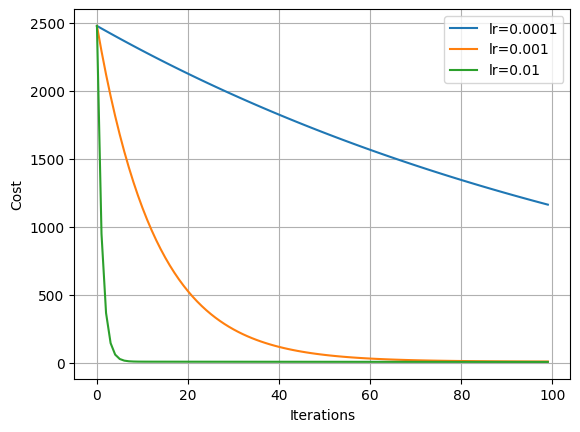


Sklearn: w = 10.000000000000002 b = 9.999999999999993


In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Data
X = np.array([1,2,3,4,5,6,7,8,9,10], float)
y = np.array([20,30,40,50,60,70,80,90,100,110], float)

# 80% train, 20% test
xtr, xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)

# Gradient Descent
def GD(x, y, lr, it=100):
    w = b = 0
    cost = []

    for i in range(it):
        pred = w*x + b
        e = pred-y
        cost.append(np.mean(e**2)/2)

        w -= lr*np.mean(e*x)
        b -= lr*np.mean(e)

    return w, b, cost

# Train
w, b, cost = GD(xtr, ytr, 0.001)

print("GD: w =", w, "b =", b)

# Test MSE
pred = w*xte + b
print("GD MSE =", np.mean((yte-pred)**2))

# Cost graph
plt.plot(cost)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost vs Iterations")
plt.grid()
plt.show()

# Learning rates
for lr in [0.0001, 0.001, 0.01]:
    _, _, c = GD(xtr, ytr, lr)
    plt.plot(c, label=f"lr={lr}")

plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.legend()
plt.grid()
plt.show()

# Scikit-learn
model = LinearRegression()
model.fit(xtr.reshape(-1,1), ytr)

print("\nSklearn: w =", model.coef_[0],
      "b =", model.intercept_)